# Data Cleaning - Customer Churn Dataset
In this step, we import necessary Python libraries for data manipulation and analysis.

In [2]:
import pandas as pd
import numpy as np

# Loading Dataset
We load the unstructured dataset into pandas DataFrame.

In [3]:
df = pd.read_csv(r"C:\Users\anita\Downloads\unstructured_churn_data.csv")
df

,CustomerID,Name,Gender,Age,City,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn,JoinDate
0,39609,,M,64,NaN,55,1923,194569,Month-to-month,??,??,NaN,2021-04-10 12:00:00
1,70446,Amit,Male,28,??,35,1379,40793,NaN,Cash,Fiber optic,0,2020-10-12 17:00:00
2,59473,??,M,33,Mumbai,36,5143,19078,1yr,Debit Card,DSL,No,2021-03-29 04:00:00
3,39818,Anita,F,44,Mumbai,68,2487,199014,One year,Unknown,dsl,NaN,2019-02-05 00:00:00
4,21713,Anita,Male,52,Hyderabad,58,1347,85791,Month-to-month,UPI,No,??,2020-01-21 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,76482,Karan,Female,22,NaN,36,2672,198719,month,Net Banking,Fiber optic,Yes,2020-09-08 09:00:00
19996,22951,Sneha,0,47,Bangalore,11,NaN,187378,Month-to-month,Credit Card,Fiber optic,0,2020-08-21 18:00:00
19997,38713,Rohit,Female,NaN,Kolkata,70,3473,70518,??,Unknown,dsl,N,2021-04-08 16:00:00
19998,72164,Sneha,1,NaN,Hyderabad,64,5522,101131,1yr,UPI,fiber,??,2020-05-24 08:00:00


# Initial Data Analysis
We check:
- Shape of dataset
- Data types
- Missing values
- Duplicate records

In [4]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       20000 non-null  int64 
 1   Name             18163 non-null  object
 2   Gender           17462 non-null  object
 3   Age              19674 non-null  object
 4   City             17402 non-null  object
 5   Tenure           19701 non-null  object
 6   MonthlyCharges   19912 non-null  object
 7   TotalCharges     19897 non-null  object
 8   Contract         17144 non-null  object
 9   PaymentMethod    20000 non-null  object
 10  InternetService  17121 non-null  object
 11  Churn            17453 non-null  object
 12  JoinDate         20000 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.0+ MB


np.int64(0)

In [5]:
df.shape

(20000, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       20000 non-null  int64 
 1   Name             18163 non-null  object
 2   Gender           17462 non-null  object
 3   Age              19674 non-null  object
 4   City             17402 non-null  object
 5   Tenure           19701 non-null  object
 6   MonthlyCharges   19912 non-null  object
 7   TotalCharges     19897 non-null  object
 8   Contract         17144 non-null  object
 9   PaymentMethod    20000 non-null  object
 10  InternetService  17121 non-null  object
 11  Churn            17453 non-null  object
 12  JoinDate         20000 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.0+ MB


In [7]:
df.isnull().sum()

CustomerID            0
Name               1837
Gender             2538
Age                 326
City               2598
Tenure              299
MonthlyCharges       88
TotalCharges        103
Contract           2856
PaymentMethod         0
InternetService    2879
Churn              2547
JoinDate              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Handling Missing and Invalid Values

The dataset contains invalid values such as:
"??", " ", "unknown"

We replace them with NaN for proper cleaning.

In [9]:
df.replace(["??", " ", "unknown"], np.nan, inplace=True)

# Standardizing Categorical Columns

We fix inconsistent values in:
- Gender
- Churn
- Contract
- InternetService

In [10]:
# Gender fix
df['Gender'] = df['Gender'].replace({
    0: "Male", 1: "Female",
    "M": "Male", "F": "Female"
})

# Churn fix
df['Churn'] = df['Churn'].replace({
    "Yes":1, "No":0, "Y":1, "N":0
})

# Contract fix
df['Contract'] = df['Contract'].replace({
    "1yr": "One year",
    "month": "Month-to-month"
})

# Internet fix
df['InternetService'] = df['InternetService'].replace({
    "fiber": "Fiber optic",
    "dsl": "DSL"
})

In [11]:
df

,CustomerID,Name,Gender,Age,City,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn,JoinDate
0,39609,NaN,Male,64,NaN,55,1923,194569,Month-to-month,NaN,NaN,NaN,2021-04-10 12:00:00
1,70446,Amit,Male,28,NaN,35,1379,40793,NaN,Cash,Fiber optic,0,2020-10-12 17:00:00
2,59473,NaN,Male,33,Mumbai,36,5143,19078,One year,Debit Card,DSL,0,2021-03-29 04:00:00
3,39818,Anita,Female,44,Mumbai,68,2487,199014,One year,Unknown,DSL,NaN,2019-02-05 00:00:00
4,21713,Anita,Male,52,Hyderabad,58,1347,85791,Month-to-month,UPI,No,NaN,2020-01-21 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,76482,Karan,Female,22,NaN,36,2672,198719,Month-to-month,Net Banking,Fiber optic,1,2020-09-08 09:00:00
19996,22951,Sneha,0,47,Bangalore,11,NaN,187378,Month-to-month,Credit Card,Fiber optic,0,2020-08-21 18:00:00
19997,38713,Rohit,Female,NaN,Kolkata,70,3473,70518,NaN,Unknown,DSL,0,2021-04-08 16:00:00
19998,72164,Sneha,1,NaN,Hyderabad,64,5522,101131,One year,UPI,Fiber optic,NaN,2020-05-24 08:00:00


In [12]:
df['Gender'] = df['Gender'].str.strip()   # spaces remove

df['Gender'] = df['Gender'].replace({
    "0": "Male",
    "1": "Female",
    "M": "Male",
    "F": "Female",
    "male": "Male",
    "female": "Female",
    "unknown": np.nan,
    "nan": np.nan
})

In [13]:
df['Gender'].value_counts(dropna=False)

Gender
Female    7514
Male      7465
NaN       5021
Name: count, dtype: int64

In [14]:
df

,CustomerID,Name,Gender,Age,City,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn,JoinDate
0,39609,NaN,Male,64,NaN,55,1923,194569,Month-to-month,NaN,NaN,NaN,2021-04-10 12:00:00
1,70446,Amit,Male,28,NaN,35,1379,40793,NaN,Cash,Fiber optic,0,2020-10-12 17:00:00
2,59473,NaN,Male,33,Mumbai,36,5143,19078,One year,Debit Card,DSL,0,2021-03-29 04:00:00
3,39818,Anita,Female,44,Mumbai,68,2487,199014,One year,Unknown,DSL,NaN,2019-02-05 00:00:00
4,21713,Anita,Male,52,Hyderabad,58,1347,85791,Month-to-month,UPI,No,NaN,2020-01-21 01:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,76482,Karan,Female,22,NaN,36,2672,198719,Month-to-month,Net Banking,Fiber optic,1,2020-09-08 09:00:00
19996,22951,Sneha,Male,47,Bangalore,11,NaN,187378,Month-to-month,Credit Card,Fiber optic,0,2020-08-21 18:00:00
19997,38713,Rohit,Female,NaN,Kolkata,70,3473,70518,NaN,Unknown,DSL,0,2021-04-08 16:00:00
19998,72164,Sneha,Female,NaN,Hyderabad,64,5522,101131,One year,UPI,Fiber optic,NaN,2020-05-24 08:00:00


# Converting Data Types

We convert numeric columns stored as strings into proper numeric format.

In [15]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Tenure'] = pd.to_numeric(df['Tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handling Missing Values

We remove rows with missing values for better analysis.

In [16]:
df.dropna(inplace=True)

# Removing Duplicate Records

In [17]:
df.drop_duplicates(inplace=True)

# Feature Engineering
We create new useful columns:
- Average Charges
- Customer Type

In [18]:
df['AvgCharges'] = df['TotalCharges'] / df['Tenure']
df['CustomerType'] = np.where(df['Tenure'] < 12, "New", "Loyal")

In [35]:
df['Churn'].unique()

array([0, 1])

In [33]:
df['Churn'] = (
    df['Churn']
    .astype(str)
    .str.strip()
    .replace({"0": 0, "1": 1, "Yes": 1, "No": 0})
    .astype(int)
)

C:\Users\anita\AppData\Local\Temp\ipykernel_4712\3646849278.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"0": 0, "1": 1, "Yes": 1, "No": 0})


In [34]:
df['Churn'] = df['Churn'].replace({
    "0": 0,
    "1": 1,
    "Yes": 1,
    "No": 0
}).infer_objects(copy=False)

# Dropping Irrelevant Columns
Columns like Name are not useful for analysis.

In [19]:
df.drop(columns=['Name'], inplace=True)

# Final Cleaned Data Overview

In [20]:
df

,CustomerID,Gender,Age,City,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn,JoinDate,AvgCharges,CustomerType
8,76931,Male,50.0,Kolkata,22.0,3403.0,114417.0,One year,Cash,Fiber optic,0,2021-01-19 16:00:00,5200.772727,Loyal
12,18926,Female,37.0,Kolkata,11.0,3723.0,19777.0,One year,Debit Card,Fiber optic,1,2020-06-06 20:00:00,1797.909091,New
14,36746,Male,61.0,Kolkata,39.0,636.0,191241.0,One year,Cash,Fiber optic,1,2020-08-11 10:00:00,4903.615385,Loyal
15,79164,Male,53.0,Bangalore,32.0,4459.0,143826.0,One year,Debit Card,Fiber optic,0,2019-09-18 03:00:00,4494.562500,Loyal
33,44138,Female,26.0,Bangalore,19.0,3723.0,84764.0,One year,Cash,Fiber optic,0,2019-10-27 22:00:00,4461.263158,Loyal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19961,37622,Male,20.0,Chennai,18.0,4171.0,106299.0,Month-to-month,Cash,No,0,2020-09-16 14:00:00,5905.500000,Loyal
19968,11900,Female,33.0,Delhi,64.0,5183.0,84764.0,One year,Net Banking,No,1,2019-07-30 06:00:00,1324.437500,Loyal
19978,70655,Male,37.0,Kolkata,42.0,2798.0,176149.0,Month-to-month,Net Banking,DSL,1,2019-12-27 15:00:00,4194.023810,Loyal
19983,73819,Female,54.0,Delhi,8.0,5934.0,80475.0,One year,Debit Card,No,0,2019-03-27 01:00:00,10059.375000,New


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2344 entries, 8 to 19989
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       2344 non-null   int64  
 1   Gender           2344 non-null   object 
 2   Age              2344 non-null   float64
 3   City             2344 non-null   object 
 4   Tenure           2344 non-null   float64
 5   MonthlyCharges   2344 non-null   float64
 6   TotalCharges     2344 non-null   float64
 7   Contract         2344 non-null   object 
 8   PaymentMethod    2344 non-null   object 
 9   InternetService  2344 non-null   object 
 10  Churn            2344 non-null   object 
 11  JoinDate         2344 non-null   object 
 12  AvgCharges       2344 non-null   float64
 13  CustomerType     2344 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 274.7+ KB


In [22]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,AvgCharges
count,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000
mean,54652.636519,43.014932,35.668089,3071.718003,98718.837031,7007.416809
std,25753.959361,14.897122,20.432809,1574.000237,58040.083444,16835.362106
min,10102.000000,18.000000,1.000000,301.000000,873.000000,13.640625
25%,32915.500000,30.000000,18.000000,1710.000000,52426.000000,1343.624308
50%,55004.000000,42.000000,36.000000,3075.000000,90881.000000,2709.081197
75%,76930.250000,56.000000,53.000000,4173.750000,142965.000000,5464.352381
max,99892.000000,69.000000,71.000000,5934.000000,199907.000000,199907.000000


In [23]:
df.head()

,CustomerID,Gender,Age,City,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn,JoinDate,AvgCharges,CustomerType
8,76931,Male,50.0,Kolkata,22.0,3403.0,114417.0,One year,Cash,Fiber optic,0,2021-01-19 16:00:00,5200.772727,Loyal
12,18926,Female,37.0,Kolkata,11.0,3723.0,19777.0,One year,Debit Card,Fiber optic,1,2020-06-06 20:00:00,1797.909091,New
14,36746,Male,61.0,Kolkata,39.0,636.0,191241.0,One year,Cash,Fiber optic,1,2020-08-11 10:00:00,4903.615385,Loyal
15,79164,Male,53.0,Bangalore,32.0,4459.0,143826.0,One year,Debit Card,Fiber optic,0,2019-09-18 03:00:00,4494.562500,Loyal
33,44138,Female,26.0,Bangalore,19.0,3723.0,84764.0,One year,Cash,Fiber optic,0,2019-10-27 22:00:00,4461.263158,Loyal


# Saving Cleaned Dataset

In [36]:
df.to_csv(r"C:\Users\anita\OneDrive\Pictures\Documents\cleaned_churn_data.csv")

# Data Visualization

In this step, we use visualization libraries to analyze patterns and trends in the dataset.

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Churn Distribution
This visualization shows the percentage of customers who have churned vs retained.

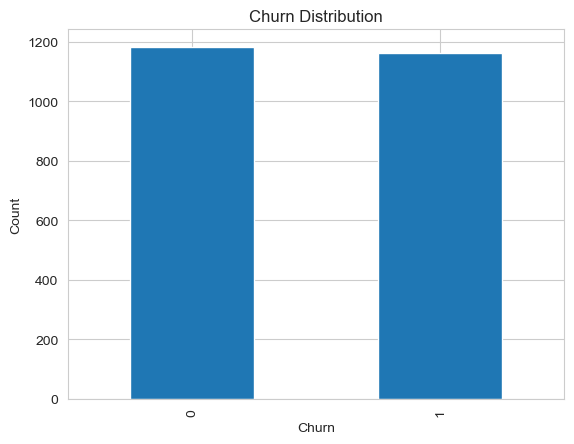

In [38]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Monthly Charges vs Churn
We analyze whether higher charges lead to higher churn.

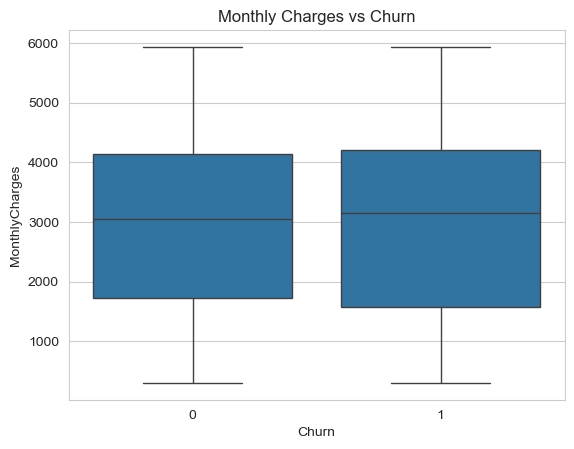

In [39]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [ ]:
# Tenure vs Churn
This shows how long customers stay before leaving.

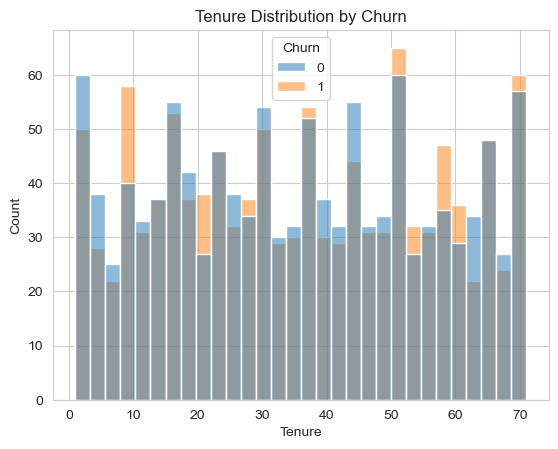

In [40]:
sns.histplot(data=df, x='Tenure', hue='Churn', bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

# Contract Type vs Churn
Analyzing how contract duration affects churn.

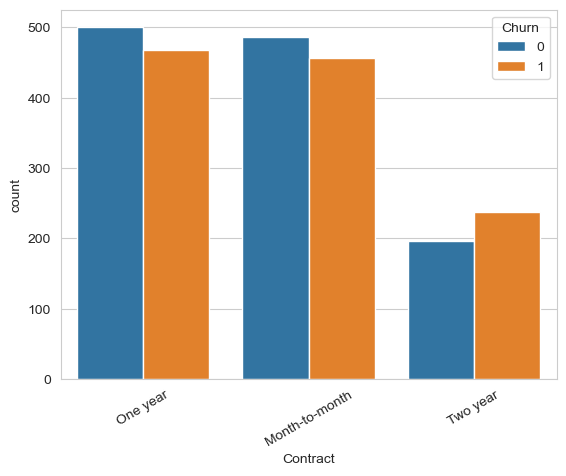

In [41]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Internet Service vs Churn

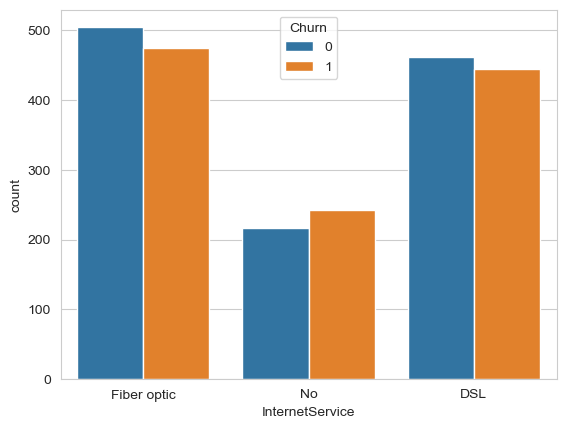

In [42]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

In [ ]:
# Customer Type vs Churn

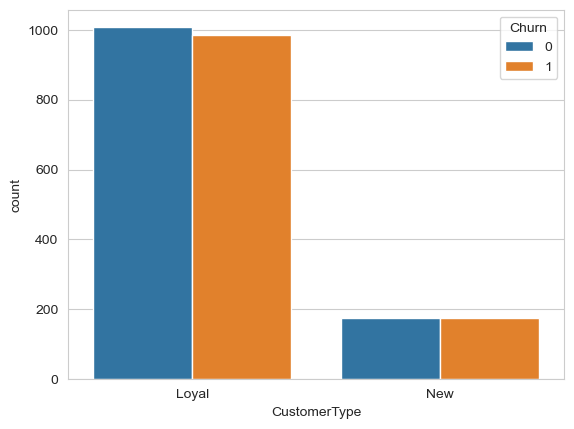

In [43]:
sns.countplot(x='CustomerType', hue='Churn', data=df)
plt.show()